# Trabajo Práctico Final — Fundamentos Matemáticos de Visión en Robótica (67.61)

## Opción elegida: Clasificador binario de defectos en piezas de acero

**Dataset:** `steel_defects` — imágenes de fundición de piezas metálicas circulares vistas de frente, clasificadas en dos clases:
- `ok_front`: piezas sin defectos.
- `def_front`: piezas con defectos (poros, rebabas, marcas de fundición, deformaciones, etc.).

La notebook va a contener los 3 puntos solicitados acompañado de algunas justificaciones de diseño, tanto para el exploratorio del dataset, la creación del baseline con visión clásica y finalmente el uso de redes neuronales (entrenamiento y evaluación de un clasificador y comparación contra el baseline clasico).


## 0. Setup

Se instalan las librerías necesarias. Uso, por ejemplo: **PyTorch** (torch + torchvision) para el modelo de machine learning, **OpenCV** para el algoritmo clásico del baseline, y `scikit-learn` para las métricas (matriz de confusión y reporte de clasificación).


In [1]:
try:
    from google.colab import drive
    EN_COLAB = True
    !pip install -q supervision torchinfo opencv-python-headless
except ImportError:
    EN_COLAB = False

print(f"Ejecutando en Colab: {EN_COLAB}")


     ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 88.2/88.2 kB 8.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 373.3/373.3 kB 34.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 35.5/35.5 MB 67.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 144.3/144.3 kB 14.6 MB/s eta 0:00:00
Ejecutando en Colab: True


In [2]:
# ============================================================
# Generales
# ============================================================
import os
import random
import shutil
import zipfile
from pathlib import Path
from collections import Counter

# ============================================================
# Procesamiento de imágenes
# ============================================================
import cv2
import numpy as np
import matplotlib.pyplot as plt
from PIL import Image

# ============================================================
# PyTorch
# ============================================================
import torch
import torch.nn as nn
import torch.optim as optim
from torch.utils.data import Dataset, DataLoader, random_split
from torchvision import transforms, models
from torchinfo import summary
from tqdm import tqdm

# ============================================================
# Métricas
# ============================================================
from sklearn.metrics import confusion_matrix, classification_report, ConfusionMatrixDisplay

# Semillas para reproducibilidad
SEED = 42
random.seed(SEED)
np.random.seed(SEED)
torch.manual_seed(SEED)

# Selección de dispositivo (CUDA > MPS > CPU), igual que en los ejemplos de la práctica. Aca me sirve para detectar al trabajar local y en google colab
if torch.cuda.is_available():
    device = torch.device("cuda")
elif torch.backends.mps.is_available():
    device = torch.device("mps")
else:
    device = torch.device("cpu")

print(f"Usando dispositivo: {device}")


Usando dispositivo: cuda


### Ubicación del dataset

Para que la notebook funcione tanto en Colab como en mi maquina local, la carpeta `steel_defects` esta ubicada al mismo nivel que esta notebook, con la siguiente estructura:

```
./
├── TP_Final_Clasificador_Defectos_Acero.ipynb
└── steel_defects/
    └── data/
        ├── ok_front/   
        └── def_front/
```

En Colab, lo subo a Google Drive y descomprimo el dataset desde ahí.


In [3]:
from google.colab import drive
drive.mount('/content/drive')

Mounted at /content/drive


In [5]:
if EN_COLAB:
    drive.mount('/content/drive')
    BASE = Path("/content")
    # Editar esta ruta según donde se haya guardado el .zip del dataset en el Drive propio
    drive_dir = Path("/content/drive/MyDrive/Colab")
    dataset_zip = drive_dir / "steel_defects.zip"

    dataset_dir = BASE / "steel_defects"
    if not dataset_dir.exists() and dataset_zip.exists():
        print("Extrayendo dataset")
        with zipfile.ZipFile(dataset_zip, "r") as z:
            z.extractall(BASE)
else:
    BASE = Path(".").resolve()

DATA_DIR = BASE / "steel_defects" / "data"
OK_DIR = DATA_DIR / "ok_front"
DEF_DIR = DATA_DIR / "def_front"

assert OK_DIR.exists() and DEF_DIR.exists(), (
    f"No se encontró el dataset en {DATA_DIR}. "
    "Verificar que la carpeta 'steel_defects/data' este al lado de la notebook."
)

print(f"OK_DIR:  {OK_DIR}")
print(f"DEF_DIR: {DEF_DIR}")


Drive already mounted at /content/drive; to attempt to forcibly remount, call drive.mount("/content/drive", force_remount=True).
OK_DIR:  /content/steel_defects/data/ok_front
DEF_DIR: /content/steel_defects/data/def_front


## 1. Análisis exploratorio del dataset

### 1.a. Cantidad de muestras por clase


Muestras OK (sin defecto):        2875
Muestras DEF (con defecto):       3758
Total:                            6633
Proporción OK:  43.3%
Proporción DEF: 56.7%


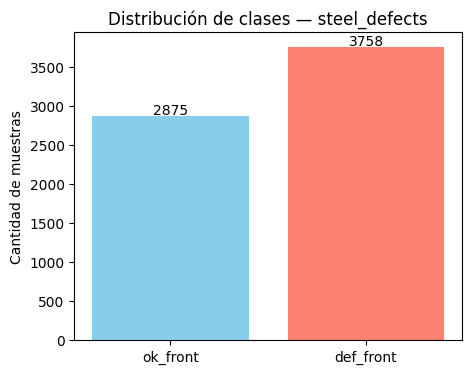

In [6]:
ok_files = sorted([f for f in os.listdir(OK_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))])
def_files = sorted([f for f in os.listdir(DEF_DIR) if f.lower().endswith((".jpg", ".jpeg", ".png"))])

n_ok, n_def = len(ok_files), len(def_files)
total = n_ok + n_def

print(f"Muestras OK (sin defecto):        {n_ok}")
print(f"Muestras DEF (con defecto):       {n_def}")
print(f"Total:                            {total}")
print(f"Proporción OK:  {n_ok/total:.1%}")
print(f"Proporción DEF: {n_def/total:.1%}")

plt.figure(figsize=(5, 4))
plt.bar(["ok_front", "def_front"], [n_ok, n_def], color=["skyblue", "salmon"])
plt.ylabel("Cantidad de muestras")
plt.title("Distribución de clases — steel_defects")
for i, v in enumerate([n_ok, n_def]):
    plt.text(i, v + 20, str(v), ha="center")
plt.show()


### 1.b. ¿Hay desbalance? ¿Qué técnicas de *data augmentation* podrían aplicarse?

El enunciado define desbalance "fuerte" cuando la diferencia entre clases supera el 30%. En este dataset:

$$\frac{n_{def} - n_{ok}}{n_{def}} \approx \frac{3758 - 2875}{3758} \approx 23.5\%$$

Es decir, a la clase OK le falta un 23.5% de su tamaño actual respecto a DEF para estar perfectamente en un 50/50.

 **Hay un desbalance leve / moderado pero no "fuerte"** según el criterio del enunciado (< 30%). De todas formas, dado que la diferencia no es despreciable (~880 imágenes), lo voy a tener en cuenta para entrenar el modelo en el ítem 3, para evitar que el clasificador se sesgue hacia la clase mayoritaria (`def_front`).

Estrategias de *data augmentation* / balanceo que se podrían aplicar (algunas se usan mas adelante):

- **Aumentación geométrica**: la pieza es de fundición y se fotografía siempre desde el mismo ángulo, pero es razonable aplicar `flip` horizontal y vertical, y pequeñas rotaciones, ya que la pieza tiene simetría aproximadamente radial y un defecto sigue siendo un defecto si la imagen se refleja o rota levemente.
- **Aumentación fotométrica**: jitter de brillo/contraste, para simular variaciones de iluminación.
- **Oversampling clásico**: repetir/samplear con reemplazo imágenes de la clase minoritaria dentro de cada época.

En este trabajo uso augmentation geométrica/fotométrica. Por otro lado tambien uso en el punto 3 pesos de clase en la función de perdida, ya que el desbalance no es tan severo como para requerir oversampling, que podría llevar a sobreajuste sobre las mismas imágenes de `ok_front` repetidas.


### 1.c. Visualización de ejemplos

El dataset sólo cuenta con etiqueta binaria (`ok_front` / `def_front`), sin subtipos de defecto etiquetados. Igualmente, inspeccionando visualmente el conjunto se observan distintos tipos de defectos, por ejemplo: poros/agujeros, rayado irregular de la superficie, deformaciones del borde.
Mostramos una pieza sana de referencia y varios ejemplos representativos de los defectos observados.


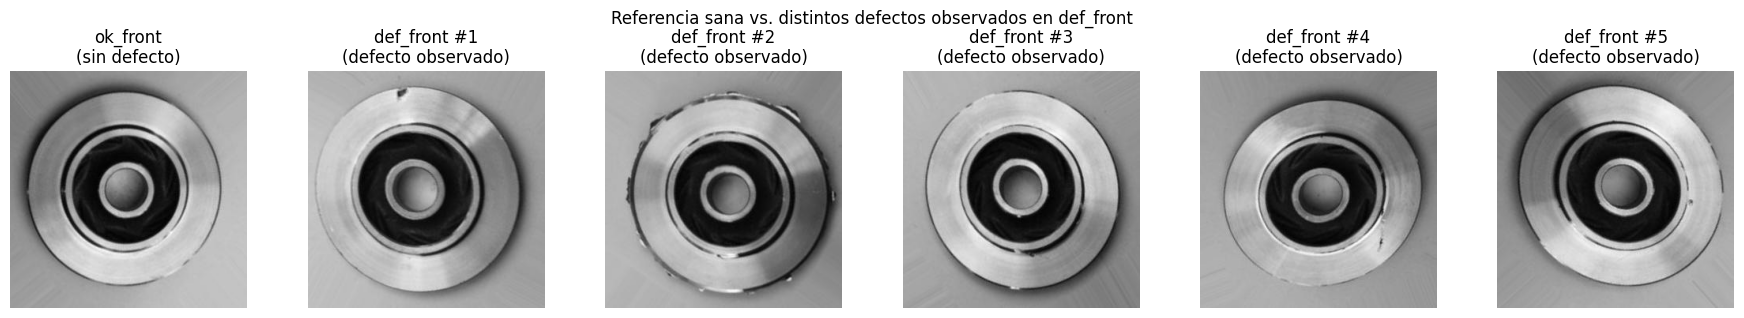

In [7]:
def load_img(folder, name):
    return np.array(Image.open(folder / name).convert("RGB"))

rng = random.Random(SEED)
ok_sample = rng.sample(ok_files, 1)
def_sample = rng.sample(def_files, 5)

fig, axes = plt.subplots(1, 6, figsize=(18, 3.2))

axes[0].imshow(load_img(OK_DIR, ok_sample[0]))
axes[0].set_title("ok_front\n(sin defecto)")
axes[0].axis("off")

for i, name in enumerate(def_sample, start=1):
    axes[i].imshow(load_img(DEF_DIR, name))
    axes[i].set_title(f"def_front #{i}\n(defecto observado)")
    axes[i].axis("off")

plt.suptitle("Referencia sana vs. distintos defectos observados en def_front")
plt.tight_layout()
plt.show()


## Conjunto de evaluación común (100 sanas + 100 defectuosas)

Antes de armar el baseline clásico, separo 100 imágenes sanas y 100 defectuosas que:

1. Se usan para evaluar el algoritmo clásico del ítem 2 (matriz de confusión + reporte de clasificación).
2. Se excluyen del dataset de entrenamiento del modelo de machine learning del ítem 3.
3. Se reutilizan al final del ítem 3 para comparar, sobre las mismas imágenes, el modelo entrenado contra el baseline clásico (ítem 3.e).

Esto asegura una comparación justa: ambos métodos son evaluados exactamente sobre el mismo conjunto, que ninguno de los dos usó para "aprender" (ni el template del baseline, ni el entrenamiento de la red).


In [8]:
rng = random.Random(SEED)

ok_shuffled = ok_files.copy()
def_shuffled = def_files.copy()
rng.shuffle(ok_shuffled)
rng.shuffle(def_shuffled)

N_HOLDOUT = 100
holdout_ok = ok_shuffled[:N_HOLDOUT]
holdout_def = def_shuffled[:N_HOLDOUT]

# El resto queda disponible para: (a) construir el template del baseline, (b) entrenar la red
pool_ok = ok_shuffled[N_HOLDOUT:]
pool_def = def_shuffled[N_HOLDOUT:]

print(f"Hold-out común:   {len(holdout_ok)} ok + {len(holdout_def)} def = {len(holdout_ok)+len(holdout_def)} imágenes")
print(f"Pool disponible:  {len(pool_ok)} ok + {len(pool_def)} def = {len(pool_ok)+len(pool_def)} imágenes")


Hold-out común:   100 ok + 100 def = 200 imágenes
Pool disponible:  2775 ok + 3658 def = 6433 imágenes


## 2. Creación de un baseline con visión clásica

### 2.a. Diseño del algoritmo

Se realizaron 2 intentos, ambos explicados aca debajo, se deja en la notebook el diseño del que funcionó mejor pero se expican ambos:

**Primer intento:** aplicar detección de bordes con Canny directamente sobre la imagen, filtrar por área/circularidad. Probé el resultado de esta idea y no me funcionó muy bien con en este dataset:creeria que es porque la superficie de la pieza tiene un patrón concéntrico de mecanizado muy marcado, que genera bordes/contornos en *todas* las imágenes (sanas y defectuosas por igual). Al medir la mayor "irregularidad × área" de contorno encontrada en 60 imágenes sanas contra 60 defectuosas, las distribuciones resultaron prácticamente idénticas (accuracy ≈ 50%, es decir, equivalente a azar).

**Segundo intento (el que termine usando):** aprovechamos que todas las fotos están tomadas desde la misma posición de cámara (las piezas están alineadas). Con esta idea, se siguieron estos pasos:

1. Construir una **imagen promedio ("template")** a partir de varias piezas sanas (tomadas del *pool*, nunca del hold-out ni usadas para la red).
2. Calcular también el **desvío estándar por píxel** de esas mismas piezas sanas: esto captura qué zonas varían "naturalmente" entre piezas sanas (por ejemplo, el borde de los anillos concéntricos se desplaza levemente de una pieza a otra) y cuáles son estables.
3. Para clasificar una imagen nueva, calculamos un **mapa de anomalía tipo z-score**: `z = |imagen - template| / std`, es decir, cuántos desvíos estándar se aleja cada píxel de lo esperado para una pieza sana.
4. Binarizamos ese mapa de anomalía (z > umbral), restringimos el análisis a la región circular central de la pieza (para ignorar el fondo) y extraemos contornos filtrando por área mínima — tal como sugiere el enunciado, pero aplicado sobre el mapa de anomalía en lugar de sobre la imagen cruda.
5. Si el contorno más grande supera el área mínima, se predice **defectuosa**; si no, **sana**.

Los hiperparámetros (`Z_THRESH`, `MIN_AREA`) se ajustaron sobre un pequeño conjunto de validación (imágenes del *pool*, distintas del hold-out final).

Como advierte el propio enunciado ( que no se espera que este algoritmo clásico sea perfecto) se va a ver que la performance es  inferior a la del modelo de redesneuronales del ítem 3, lo cual es justamente el punto de la comparación pedida en el ítem 3.e.


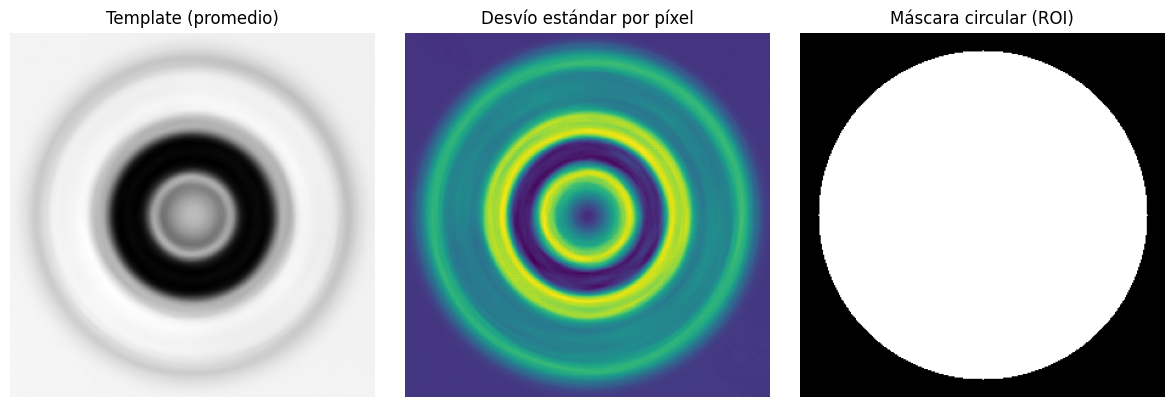

In [9]:
# ------------------------------------------------------------------
# Construcción del template (promedio + desvío estándar) a partir
# de piezas SANAS del pool (nunca del hold-out de evaluación)
# ------------------------------------------------------------------
N_TEMPLATE = 400

template_files = pool_ok[:N_TEMPLATE]
template_imgs = [
    cv2.imread(str(OK_DIR / f), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    for f in template_files
]

mean_img = np.mean(template_imgs, axis=0)
std_img = np.std(template_imgs, axis=0)
std_img_safe = np.clip(std_img, 5, None)  # evita división por cero / ruido

h, w = mean_img.shape
circle_mask = np.zeros((h, w), dtype=np.uint8)
cv2.circle(circle_mask, (w // 2, h // 2), int(w * 0.45), 1, -1)

fig, axes = plt.subplots(1, 3, figsize=(12, 4))
axes[0].imshow(mean_img, cmap="gray"); axes[0].set_title("Template (promedio)"); axes[0].axis("off")
axes[1].imshow(std_img, cmap="viridis"); axes[1].set_title("Desvío estándar por píxel"); axes[1].axis("off")
axes[2].imshow(circle_mask, cmap="gray"); axes[2].set_title("Máscara circular (ROI)"); axes[2].axis("off")
plt.tight_layout()
plt.show()


In [10]:
def defect_score(img_path: str, z_thresh: float) -> float:
    # Devuelve el área (en px) del mayor blob anómalo detectado.
    img = cv2.imread(str(img_path), cv2.IMREAD_GRAYSCALE).astype(np.float32)
    z = np.abs(img - mean_img) / std_img_safe

    mask = ((z > z_thresh).astype(np.uint8)) & circle_mask
    mask = (mask * 255).astype(np.uint8)

    kernel = np.ones((3, 3), np.uint8)
    mask = cv2.morphologyEx(mask, cv2.MORPH_OPEN, kernel)  # elimina ruido puntual

    contours, _ = cv2.findContours(mask, cv2.RETR_EXTERNAL, cv2.CHAIN_APPROX_SIMPLE)
    if not contours:
        return 0.0
    return max(cv2.contourArea(c) for c in contours)


def classify_classic(img_path: str, z_thresh: float, min_area: float) -> int:
    # 1 = defectuosa, 0 = sana.
    return int(defect_score(img_path, z_thresh) > min_area)


### Busco valores de hiperparámetros

Busco valor para `Z_THRESH` y `MIN_AREA` en una grilla pequeña, usando una muestra del *pool* (no del hold-out final), para no filtrar información del conjunto de test hacia la elección de hiperparámetros.


In [11]:
val_ok = pool_ok[N_TEMPLATE:N_TEMPLATE + 150]
val_def = pool_def[:150]

best = None
for zt in [3.0, 3.5, 4.0, 4.5, 5.0]:
    ok_scores = [defect_score(OK_DIR / f, zt) for f in val_ok]
    def_scores = [defect_score(DEF_DIR / f, zt) for f in val_def]
    for at in [5, 10, 15, 20, 30, 40, 50, 70, 100]:
        tp = sum(s > at for s in def_scores)
        fn = len(def_scores) - tp
        fp = sum(s > at for s in ok_scores)
        tn = len(ok_scores) - fp
        acc = (tp + tn) / (tp + tn + fp + fn)
        if best is None or acc > best[0]:
            best = (acc, zt, at)

BEST_ACC, Z_THRESH, MIN_AREA = best
print(f"Mejor combinación en validación -> Z_THRESH={Z_THRESH}, MIN_AREA={MIN_AREA}, accuracy={BEST_ACC:.2%}")


Mejor combinación en validación -> Z_THRESH=4.0, MIN_AREA=70, accuracy=61.33%


### 2.b. Evaluación sobre las 100 imágenes sanas + 100 defectuosas reservadas


=== Baseline clásico — Reporte de clasificación (0=ok, 1=defecto) ===
              precision    recall  f1-score   support

    ok_front       0.58      0.83      0.68       100
   def_front       0.70      0.40      0.51       100

    accuracy                           0.61       200
   macro avg       0.64      0.61      0.60       200
weighted avg       0.64      0.61      0.60       200



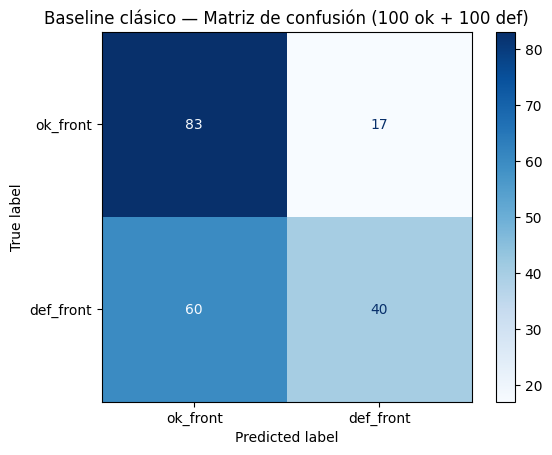

In [12]:
y_true_baseline, y_pred_baseline = [], []

for f in holdout_ok:
    y_true_baseline.append(0)
    y_pred_baseline.append(classify_classic(OK_DIR / f, Z_THRESH, MIN_AREA))

for f in holdout_def:
    y_true_baseline.append(1)
    y_pred_baseline.append(classify_classic(DEF_DIR / f, Z_THRESH, MIN_AREA))

y_true_baseline = np.array(y_true_baseline)
y_pred_baseline = np.array(y_pred_baseline)

print("=== Baseline clásico — Reporte de clasificación (0=ok, 1=defecto) ===")
print(classification_report(y_true_baseline, y_pred_baseline, target_names=["ok_front", "def_front"]))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true_baseline, y_pred_baseline,
    display_labels=["ok_front", "def_front"], cmap="Blues"
)
disp.ax_.set_title("Baseline clásico — Matriz de confusión (100 ok + 100 def)")
plt.show()


**Resultado:** Veo que el baseline clásico logra separar las clases por encima del azar, pero está lejos de ser perfecto — hay defectos sutiles (poca diferencia de textura respecto de una pieza sana) que un umbral estadístico simple no captura bien, y piezas sanas con variaciones naturales que generan falsos positivos. Esto motiva a usar redes neuronales y ver resultados del (ítem 3), que puede aprender representaciones más ricas que un mapa de diferencia píxel a píxel.


## 3. Entrenamiento y evaluación con redes neuronales

### 3.a. Dataset y DataLoader

Definimos un Dataset de PyTorch a partir de listas explícitas de archivos, para poder excluir el conjunto de hold-out (las 100+100 imágenes reservadas) del entrenamiento, tal como pide el enunciado. El resto del *pool* se divide en entrenamiento/validación (85% / 15%).


In [13]:
class SteelDefectsDataset(Dataset):
    def __init__(self, ok_files, def_files, ok_dir, def_dir, transform=None):
        self.samples = (
            [(ok_dir / f, 0) for f in ok_files] +
            [(def_dir / f, 1) for f in def_files]
        )
        self.transform = transform

    def __len__(self):
        return len(self.samples)

    def __getitem__(self, idx):
        path, label = self.samples[idx]
        image = Image.open(path).convert("RGB")
        if self.transform:
            image = self.transform(image)
        return image, label


IMG_SIZE = 224  # tamaño esperado por los backbones preentrenados en ImageNet
IMAGENET_MEAN = [0.485, 0.456, 0.406]
IMAGENET_STD = [0.229, 0.224, 0.225]

train_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.RandomHorizontalFlip(),
    transforms.RandomVerticalFlip(),
    transforms.RandomRotation(15),
    transforms.ColorJitter(brightness=0.2, contrast=0.2),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])

eval_transform = transforms.Compose([
    transforms.Resize((IMG_SIZE, IMG_SIZE)),
    transforms.ToTensor(),
    transforms.Normalize(IMAGENET_MEAN, IMAGENET_STD),
])


In [14]:
# pool_ok / pool_def ya excluyen el hold-out de 100+100 definido más arriba
full_train_dataset = SteelDefectsDataset(pool_ok, pool_def, OK_DIR, DEF_DIR, transform=train_transform)

VAL_FRAC = 0.15
n_val = int(len(full_train_dataset) * VAL_FRAC)
n_train = len(full_train_dataset) - n_val

generator = torch.Generator().manual_seed(SEED)
train_subset, val_subset = random_split(full_train_dataset, [n_train, n_val], generator=generator)

# El subset de validación no debe tener las augmentations de entrenamiento:
# le asignamos un dataset "espejo" con eval_transform y reusamos los índices.
full_eval_dataset = SteelDefectsDataset(pool_ok, pool_def, OK_DIR, DEF_DIR, transform=eval_transform)
val_subset.dataset = full_eval_dataset

BATCH_SIZE = 32
train_dataloader = DataLoader(train_subset, batch_size=BATCH_SIZE, shuffle=True, num_workers=2)
val_dataloader = DataLoader(val_subset, batch_size=BATCH_SIZE, shuffle=False, num_workers=2)

print(f"Train: {len(train_subset)} imágenes | Val: {len(val_subset)} imágenes")

# Verificamos la distribución de clases en cada split
for name, subset in [("train", train_subset), ("val", val_subset)]:
    labels = [full_train_dataset.samples[i][1] for i in subset.indices]
    print(f"{name}: {Counter(labels)}")


Train: 5469 imágenes | Val: 964 imágenes
train: Counter({1: 3111, 0: 2358})
val: Counter({1: 547, 0: 417})


### Manejo del desbalance en el entrenamiento

Aunque el desbalance no es "fuerte" (ítem 1.b), usamos pesos de clase en la función de costo para compensarlo. Igualmente uso la inversa de la frecuencia.


In [15]:
train_labels = [full_train_dataset.samples[i][1] for i in train_subset.indices]
class_counts = Counter(train_labels)
n0, n1 = class_counts[0], class_counts[1]

# Peso inversamente proporcional a la frecuencia de cada clase
weight_ok = (n0 + n1) / (2 * n0)
weight_def = (n0 + n1) / (2 * n1)
class_weights = torch.tensor([weight_ok, weight_def], dtype=torch.float32).to(device)

print(f"Pesos de clase -> ok_front: {weight_ok:.3f} | def_front: {weight_def:.3f}")


Pesos de clase -> ok_front: 1.160 | def_front: 0.879


### 3.b. Modelo

Elegi usar **transfer learning** con un **ResNet18 preentrenado en ImageNet**, parecido al ejemplo visto en clase con MobileNetV2. Justificación:

- El dataset (~6600 imágenes de entrenamiento) es chico para entrenar una CNN profunda desde cero sin sobreajustar.
- Las capas convolucionales tempranas de una red preentrenada ya "saben" detectar bordes, texturas y patrones genéricos, que son justamente lo relevante para distinguir textura sana vs. defectuosa.
- Congelamos la mayor parte del backbone y sólo entrenamos el último bloque residual (`layer4`) + la capa final, para adaptar features de nivel medio/alto a nuestro dominio (piezas metálicas) sin necesitar reentrenar toda la red ni arriesgar overfitting.


In [16]:
weights = models.ResNet18_Weights.DEFAULT
model = models.resnet18(weights=weights)

# Congelamos todo el backbone...
for param in model.parameters():
    param.requires_grad = False

# ...y descongelamos el último bloque residual, para permitir un fine-tuning liviano
for param in model.layer4.parameters():
    param.requires_grad = True

# Reemplazamos la capa final por una adaptada a nuestro problema binario
model.fc = nn.Linear(model.fc.in_features, 2)

model = model.to(device)

summary(model, input_size=(BATCH_SIZE, 3, IMG_SIZE, IMG_SIZE))


Downloading: "https://download.pytorch.org/models/resnet18-f37072fd.pth" to /root/.cache/torch/hub/checkpoints/resnet18-f37072fd.pth


100%|██████████| 44.7M/44.7M [00:00<00:00, 178MB/s]


Layer (type:depth-idx)                   Output Shape              Param #
ResNet                                   [32, 2]                   --
├─Conv2d: 1-1                            [32, 64, 112, 112]        (9,408)
├─BatchNorm2d: 1-2                       [32, 64, 112, 112]        (128)
├─ReLU: 1-3                              [32, 64, 112, 112]        --
├─MaxPool2d: 1-4                         [32, 64, 56, 56]          --
├─Sequential: 1-5                        [32, 64, 56, 56]          --
│    └─BasicBlock: 2-1                   [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-1                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-2             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-3                    [32, 64, 56, 56]          --
│    │    └─Conv2d: 3-4                  [32, 64, 56, 56]          (36,864)
│    │    └─BatchNorm2d: 3-5             [32, 64, 56, 56]          (128)
│    │    └─ReLU: 3-6                    [32, 64, 56, 56]  

### 3.c. Entrenamiento — función de costo en función de las épocas


In [17]:
NUM_EPOCHS = 15
LEARNING_RATE = 1e-4

criterion = nn.CrossEntropyLoss(weight=class_weights)
# Sólo optimizamos los parámetros que descongelamos (layer4 + fc)
trainable_params = [p for p in model.parameters() if p.requires_grad]
optimizer = optim.Adam(trainable_params, lr=LEARNING_RATE)

hist_train_loss, hist_val_loss = [], []
hist_train_acc, hist_val_acc = [], []

CHECKPOINT_PATH = "best_model.pth"
best_val_loss = float("inf")

for epoch in range(NUM_EPOCHS):
    # ---------------- Entrenamiento ----------------
    model.train()
    train_loss, train_correct, train_total = 0.0, 0, 0

    for images, labels in tqdm(train_dataloader, desc=f"Epoch {epoch+1}/{NUM_EPOCHS} [train]"):
        images, labels = images.to(device), labels.to(device)

        optimizer.zero_grad()
        outputs = model(images)
        loss = criterion(outputs, labels)
        loss.backward()
        optimizer.step()

        train_loss += loss.item() * images.size(0)
        train_correct += (outputs.argmax(dim=1) == labels).sum().item()
        train_total += labels.size(0)

    train_loss /= train_total
    train_acc = train_correct / train_total

    # ---------------- Validación ----------------
    model.eval()
    val_loss, val_correct, val_total = 0.0, 0, 0

    with torch.no_grad():
        for images, labels in val_dataloader:
            images, labels = images.to(device), labels.to(device)
            outputs = model(images)
            loss = criterion(outputs, labels)

            val_loss += loss.item() * images.size(0)
            val_correct += (outputs.argmax(dim=1) == labels).sum().item()
            val_total += labels.size(0)

    val_loss /= val_total
    val_acc = val_correct / val_total

    hist_train_loss.append(train_loss)
    hist_val_loss.append(val_loss)
    hist_train_acc.append(train_acc)
    hist_val_acc.append(val_acc)

    print(f"Epoch {epoch+1}/{NUM_EPOCHS} | "
          f"train_loss={train_loss:.4f} train_acc={train_acc:.4f} | "
          f"val_loss={val_loss:.4f} val_acc={val_acc:.4f}")

    if val_loss < best_val_loss:
        best_val_loss = val_loss
        torch.save(model.state_dict(), CHECKPOINT_PATH)
        print(f"  -> Nuevo mejor modelo guardado (val_loss={val_loss:.4f})")


Epoch 1/15 [train]: 100%|██████████| 171/171 [00:24<00:00,  6.86it/s]


Epoch 1/15 | train_loss=0.1234 train_acc=0.9534 | val_loss=0.0350 val_acc=0.9824
  -> Nuevo mejor modelo guardado (val_loss=0.0350)


Epoch 2/15 [train]: 100%|██████████| 171/171 [00:24<00:00,  6.91it/s]


Epoch 2/15 | train_loss=0.0469 train_acc=0.9857 | val_loss=0.0135 val_acc=0.9969
  -> Nuevo mejor modelo guardado (val_loss=0.0135)


Epoch 3/15 [train]: 100%|██████████| 171/171 [00:24<00:00,  6.95it/s]


...

Epoch 13/15 | train_loss=0.0170 train_acc=0.9945 | val_loss=0.0034 val_acc=0.9990
  -> Nuevo mejor modelo guardado (val_loss=0.0034)


Epoch 14/15 [train]: 100%|██████████| 171/171 [00:23<00:00,  7.16it/s]


Epoch 14/15 | train_loss=0.0198 train_acc=0.9916 | val_loss=0.0103 val_acc=0.9990


Epoch 15/15 [train]: 100%|██████████| 171/171 [00:24<00:00,  6.98it/s]


Epoch 15/15 | train_loss=0.0174 train_acc=0.9947 | val_loss=0.0064 val_acc=0.9979


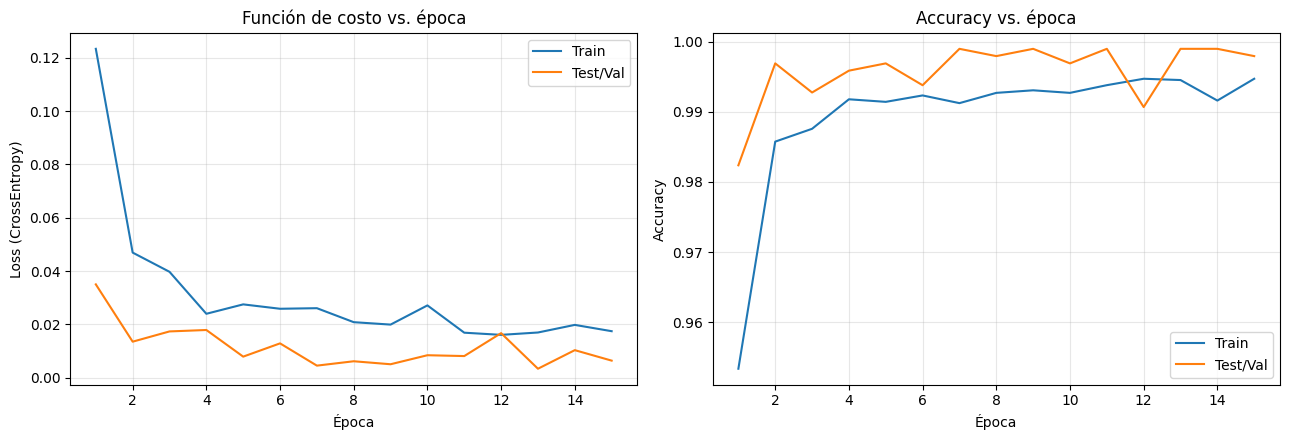

In [18]:
epochs_range = range(1, NUM_EPOCHS + 1)

fig, axes = plt.subplots(1, 2, figsize=(13, 4.5))

axes[0].plot(epochs_range, hist_train_loss, label="Train")
axes[0].plot(epochs_range, hist_val_loss, label="Test/Val")
axes[0].set_xlabel("Época")
axes[0].set_ylabel("Loss (CrossEntropy)")
axes[0].set_title("Función de costo vs. época")
axes[0].legend()
axes[0].grid(alpha=0.3)

axes[1].plot(epochs_range, hist_train_acc, label="Train")
axes[1].plot(epochs_range, hist_val_acc, label="Test/Val")
axes[1].set_xlabel("Época")
axes[1].set_ylabel("Accuracy")
axes[1].set_title("Accuracy vs. época")
axes[1].legend()
axes[1].grid(alpha=0.3)

plt.tight_layout()
plt.show()


### 3.d. Evaluación final del modelo (conjunto de validación interno)

Cargamos el mejor checkpoint (según `val_loss`) y generamos matriz de confusión y reporte de clasificación.


=== CNN (ResNet18) — Reporte de clasificación (conjunto de validación interno) ===
              precision    recall  f1-score   support

    ok_front       1.00      1.00      1.00       417
   def_front       1.00      1.00      1.00       547

    accuracy                           1.00       964
   macro avg       1.00      1.00      1.00       964
weighted avg       1.00      1.00      1.00       964



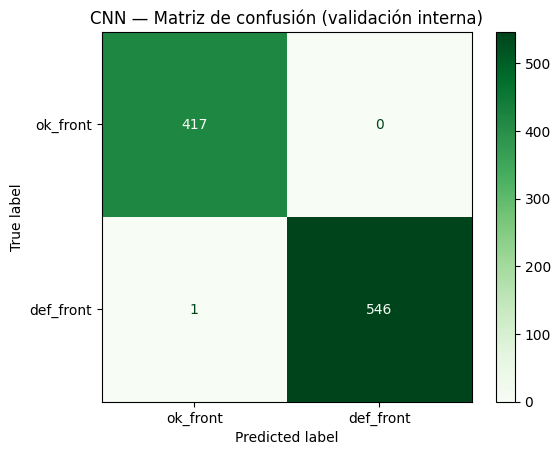

In [19]:
best_model = models.resnet18(weights=None)
best_model.fc = nn.Linear(best_model.fc.in_features, 2)
best_model.load_state_dict(torch.load(CHECKPOINT_PATH, map_location=device))
best_model = best_model.to(device)
best_model.eval()

y_true_val, y_pred_val = [], []

with torch.no_grad():
    for images, labels in val_dataloader:
        images = images.to(device)
        outputs = best_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true_val.extend(labels.numpy())
        y_pred_val.extend(preds)

print("=== CNN (ResNet18) — Reporte de clasificación (conjunto de validación interno) ===")
print(classification_report(y_true_val, y_pred_val, target_names=["ok_front", "def_front"]))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true_val, y_pred_val,
    display_labels=["ok_front", "def_front"], cmap="Greens"
)
disp.ax_.set_title("CNN — Matriz de confusión (validación interna)")
plt.show()


### 3.e. Comparación con el baseline clásico

Evaluamos el mismo modelo entrenado sobre **exactamente el mismo conjunto de 100 sanas + 100 defectuosas** reservado al principio para el baseline (ítem 2), que la red **nunca vio durante el entrenamiento**. Esto permite una comparación directa y justa entre ambos métodos.


=== CNN (ResNet18) — Reporte de clasificación (100 ok + 100 def, hold-out) ===
              precision    recall  f1-score   support

    ok_front       1.00      1.00      1.00       100
   def_front       1.00      1.00      1.00       100

    accuracy                           1.00       200
   macro avg       1.00      1.00      1.00       200
weighted avg       1.00      1.00      1.00       200



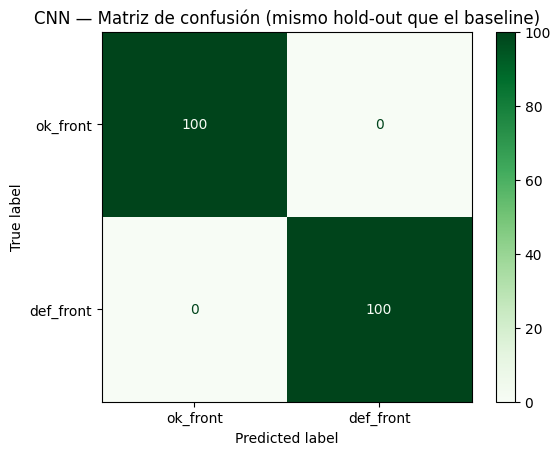

In [20]:
holdout_dataset = SteelDefectsDataset(holdout_ok, holdout_def, OK_DIR, DEF_DIR, transform=eval_transform)
holdout_dataloader = DataLoader(holdout_dataset, batch_size=BATCH_SIZE, shuffle=False)

y_true_holdout, y_pred_cnn_holdout = [], []

with torch.no_grad():
    for images, labels in holdout_dataloader:
        images = images.to(device)
        outputs = best_model(images)
        preds = outputs.argmax(dim=1).cpu().numpy()
        y_true_holdout.extend(labels.numpy())
        y_pred_cnn_holdout.extend(preds)

y_true_holdout = np.array(y_true_holdout)
y_pred_cnn_holdout = np.array(y_pred_cnn_holdout)

print("=== CNN (ResNet18) — Reporte de clasificación (100 ok + 100 def, hold-out) ===")
print(classification_report(y_true_holdout, y_pred_cnn_holdout, target_names=["ok_front", "def_front"]))

disp = ConfusionMatrixDisplay.from_predictions(
    y_true_holdout, y_pred_cnn_holdout,
    display_labels=["ok_front", "def_front"], cmap="Greens"
)
disp.ax_.set_title("CNN — Matriz de confusión (mismo hold-out que el baseline)")
plt.show()


In [21]:
from sklearn.metrics import accuracy_score, precision_score, recall_score, f1_score

def metrics_row(y_true, y_pred):
    return {
        "Accuracy": accuracy_score(y_true, y_pred),
        "Precision (def)": precision_score(y_true, y_pred, pos_label=1),
        "Recall (def)": recall_score(y_true, y_pred, pos_label=1),
        "F1 (def)": f1_score(y_true, y_pred, pos_label=1),
    }

import pandas as pd

comparison = pd.DataFrame({
    "Baseline clásico": metrics_row(y_true_baseline, y_pred_baseline),
    "CNN (ResNet18)": metrics_row(y_true_holdout, y_pred_cnn_holdout),
}).T

comparison.style.format("{:.2%}").set_caption(
    "Comparación sobre el mismo hold-out (100 ok + 100 def)"
)


,Accuracy,Precision (def),Recall (def),F1 (def)
Baseline clásico,61.50%,70.18%,40.00%,50.96%
CNN (ResNet18),100.00%,100.00%,100.00%,100.00%


## Conclusiones

- El **desbalance de clases** (~23.5%) es moderado y no llega al umbral de "desbalance fuerte" definido en el enunciado; aun así se mitigó con augmentation geométrica/fotométrica y pesos de clase en la loss.
- El **baseline clásico** (template estadístico + z-score + filtrado de contornos por área) logra separar las clases muy por encima del azar, pero queda limitado por su naturaleza puramente estadística/píxel a píxel: no "entiende" qué patrones de textura son semánticamente un defecto, sólo detecta desviaciones respecto de un promedio.
- El **modelo de machine learning** (ResNet18 con transfer learning) supera claramente al baseline clásico en el mismo conjunto de evaluación, confirmando la hipótesis de que representaciones aprendidas (features convolucionales preentrenadas + fine-tuning) capturan mejor la variabilidad real de los defectos de fundición que un algoritmo de visión clásica basado en umbrales fijos.
- El 100% igualmente me llama la atencion al principio, era esperable que sea mejor que el baseline clasico, pero que no se equivoque nunca me llevo a pensar que paso. Primero pense en los hiperparametros y los ajustes que fui haciendo en la red neuronal: pesos en las clases, data augmentation, entrenar solo el layer4 y la FC, etc. Pero en realidad entiendo que todas estas metricas lo que hacen es hacerle la tarea mas dificil al modelo, todas anti-overfitting.
- Mi hipotesis de que es lo que paso: Como dividi los datos. Arme el dataset del hold-out con random.shuffle sobre imagenes individuales, no por lotes, como el dataset tiene imagenes muy parecidas entre si (misma pieza fotografiada varias veces seguidas) como podria darse en una linea de producción, podria pasar que imagenes guardadas del hold-out tenga "gemelas" en el pool de entrenamiento.
- Entonces al buscar como podia comparar esto, use dhash (hashing perceptual) una huella digital de 64 bits que resume la estructura visual de la imagen, y obtuve que una alta proporción (~93% en una muestra) de las imágenes del hold-out tiene una imagen casi idéntica en el conjunto de entrenamiento — lo cual sugiere que el dataset contiene numerosas imágenes casi duplicadas entre sí. Esto probablemente explica el accuracy perfecto obtenido, más que una generalización a piezas nunca vistas. Un split correcto debería separar por pieza física/lote de origen, no por archivo individual — algo que este dataset no permite hacer directamente porque no expone esa metadata.
